Olá, **Luisa**!

Meu nome é **Gabriel Aguiar** e serei o revisor do seu projeto hoje.

Quando identificar um erro pela primeira vez, apenas vou apontá-lo para que você mesmo possa encontrá-lo e corrigi-lo. Ao longo do notebook também farei observações de melhoria e comentários sobre suas análises — meu objetivo é prepará-lo(a) para trabalhar como **Data Analyst** no mercado real.

Se não conseguir identificar o erro, na próxima iteração darei uma dica mais precisa com exemplos práticos. Estou aberto a feedbacks e discussões.

**Por favor, não mova, modifique ou exclua meus comentários.**

Você encontrará meus comentários em caixas coloridas:

<div class="alert alert-block alert-success">
<b>Comentário do revisor (Gabriel Aguiar):</b> <a class="tocSkip"></a>
Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor (Gabriel Aguiar):</b> <a class="tocSkip"></a>
Atenção. Sugestão ou observação de melhoria.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário do revisor (Gabriel Aguiar):</b> <a class="tocSkip"></a>
Precisa de correção. O projeto não pode ser aceito com comentários em vermelho abertos.
</div>

Você pode me responder usando:

<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b>Comentário geral do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Luisa, obrigado por enviar seu projeto! Você fez um bom trabalho. A análise exploratória está muito completa: você comparou as médias entre clientes que ficaram e os que saíram, leu a matriz de correlação com profundidade e identificou até pares de variáveis multicolineares. Os dois modelos de classificação foram treinados e comparados corretamente, e a segmentação por K-Means não usa a coluna `churn` como feature, o que evita um erro clássico dessa etapa (o algoritmo "enxergar" a resposta que ele deveria prever). O perfil dos cinco clusters está muito bem descrito e as recomendações de marketing no fechamento são específicas e conectadas aos números encontrados.

Fique à vontade para avançar para o próximo sprint. Qualquer dúvida, conte comigo. Até breve!
</div>

A rede de academias Model Fitness busca desenvolver uma estratégia de interação e retenção de clientes baseada em dados analíticos. Um dos principais desafios enfrentados pelo setor é a rotatividade de clientes (churn), que ocorre quando um cliente deixa de frequentar a academia ou não renova seu contrato. Diferentemente de outros tipos de serviços, em uma academia a ausência prolongada de um cliente pode ser um forte indicador de que ele não pretende continuar utilizando o serviço.

Nesse contexto, a análise de dados pode ajudar a identificar antecipadamente os clientes com maior probabilidade de abandonar a academia, permitindo que a empresa tome medidas preventivas para aumentar a retenção e melhorar o relacionamento com seus clientes.

O principal objetivo deste projeto é analisar os dados dos clientes da Model Fitness para identificar padrões relacionados à rotatividade e desenvolver estratégias de retenção baseadas em evidências.

Para isso, serão realizadas as seguintes etapas:

- Análise exploratória dos dados, investigando as características dos clientes e identificando possíveis padrões relacionados à rotatividade;
- Padronização dos dados, garantindo que as diferentes escalas das variáveis não influenciem de forma inadequada as análises de agrupamento;
- Análise da relação entre as características dos clientes e o churn, buscando identificar quais fatores estão mais associados à saída dos clientes;
- Construção e avaliação de modelos preditivos, utilizando regressão logística e floresta aleatória, para prever a probabilidade de rotatividade dos clientes;
- Agrupamento dos clientes por métodos de clusterização, inicialmente utilizando o agrupamento hierárquico e o dendrograma para analisar a estrutura dos grupos e estimar uma quantidade adequada de agrupamentos;
- Aplicação do algoritmo K-Means, utilizando 5 agrupamentos, conforme definido no projeto, para segmentar os clientes de acordo com características e comportamentos semelhantes;
- Análise dos agrupamentos, comparando as médias e as distribuições das características dos clientes em cada cluster, além das respectivas taxas de rotatividade;
- Construção de retratos de usuários típicos, identificando os grupos mais marcantes, suas principais características, níveis de engajamento e comportamento em relação à academia;
- Identificação dos grupos mais propensos à saída e dos grupos mais leais, permitindo estabelecer diferentes níveis de prioridade para as ações de retenção;
- Elaboração de recomendações de marketing e retenção, direcionadas aos diferentes perfis de clientes, com o objetivo de reduzir a rotatividade, aumentar o engajamento e fortalecer o relacionamento com a academia.

Ao final, a análise permitirá compreender melhor o comportamento dos clientes da Model Fitness, identificar os principais fatores associados à rotatividade e propor ações de retenção segmentadas, direcionando os esforços da academia para os grupos que apresentam maior risco de saída e, ao mesmo tempo, fortalecendo a fidelização dos clientes mais engajados.

# Passo 1. Carregando os dados e preparando-os para a análise

In [1]:
# Importando as bibliotecas

# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Divisão dos dados
from sklearn.model_selection import train_test_split

# Padronização
from sklearn.preprocessing import StandardScaler

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Agrupamento K-Means
from sklearn.cluster import KMeans

# Clusterização hierárquica / dendrograma
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
# lendo o conjunto de dados do dataset gym_churn_us
gym_churn_us = pd.read_csv('/datasets/gym_churn_us.csv')

# Passo 2. Realizando a análise exploratória dos dados (AED)

In [3]:
# Imprimindo as 5 primeiras linhas do dataset gym_churn_us
gym_churn_us.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
# Imprimindo as 5 últimas linhas do dataset gym_churn_us
gym_churn_us.tail()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0
3999,1,0,1,0,0,12,1,30,178.861814,12.0,1,1.101832,1.035270,0


In [5]:
# Imprimindo as informações do dataset gym_churn_us e determinando o tamanho exato dos dados
gym_churn_us.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Os tipos de dados estão adequados para a análise. As variáveis binárias estão representadas por 0 e 1, e as variáveis numéricas estão nos formatos int64 e float64. Portanto, não foi necessária nenhuma conversão de tipos.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa leitura do `info()`. Confirmar que as variáveis binárias já vêm como 0/1 e que os tipos `int64`/`float64` são coerentes com o que cada coluna representa evita trabalho de conversão mais à frente — é o primeiro passo certo antes de qualquer análise.
</div>

In [6]:
# Verificando se há valores ausentes no dataset gym_churn_us
gym_churn_us.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Não foram encontrados dados ausentes.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Isso mesmo, `isna().sum()` retornando zero em todas as colunas confirma que não há valores ausentes no dataset. Checar isso antes de seguir para a modelagem é um hábito importante.
</div>

In [7]:
# Imprimindo um resumo estatístico das colunas numéricas do dataset gym_churn_us
gym_churn_us.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


A partir do método describe(), analisamos a média e o desvio padrão das características do conjunto de dados:

- A idade média dos clientes é de aproximadamente 29.2 anos, com desvio padrão em torno de 3.26 anos.
- O período médio de contrato é de aproximadamente 4.68 meses, com desvio padrão em torno de 4.55 meses, indicando uma grande variação entre os tipos de contrato.
- O tempo médio de permanência dos clientes (Lifetime) é de aproximadamente 3.72 meses, com desvio padrão em torno de 3.75 meses, indicando também uma enorme variação.
- A frequência média de visitas durante todo o período do cliente é de aproximadamente 1.88 vezes por semana, com desvio padrão em torno de 0.97.
- A frequência média no mês atual é de aproximadamente 1.77 vezes por semana, com desvio padrão em torno de 1,05.
- A variável Churn apresenta média de 0.265, indicando que aproximadamente 26.5% dos clientes estão em situação de rotatividade.

Conclusão: As variáveis apresentam diferentes níveis de dispersão. Algumas, como idade, possuem menor variação, enquanto outras, como período de contrato e tempo de permanência apresentam maior dispersão em relação à média.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Leitura muito boa do `describe()`. Você não só reportou os números, como interpretou a dispersão de cada variável: idade média de 29.2 anos com baixa variação, contra período de contrato (4.68 meses) e lifetime (3.72 meses) com desvio-padrão quase do tamanho da própria média, o que já indica bastante heterogeneidade entre os clientes. Também traduziu corretamente a média de 0.265 da coluna `churn` como 26.5% de rotatividade.
</div>

In [8]:
# Mostrando o número de linhas e colunas do dataset gym_churn_us
gym_churn_us.shape

(4000, 14)

In [9]:
# Mostrando o nome das colunas do dataset gym_churn_us
gym_churn_us.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')

In [10]:
# Tranformando os nomes das colunas do dataset gym_churn_us em letras minúsculas para padronização dos nomes
gym_churn_us.columns = gym_churn_us.columns.str.lower()
print(gym_churn_us.columns)

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')


In [11]:
# Verificando se há linhas completamente duplicadas no dataset gym_churn_us
gym_churn_us.duplicated().sum()

0

Não foram encontrados dados duplicados.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Confirmado, `duplicated().sum()` igual a zero. Junto com a checagem de ausentes, isso fecha bem a etapa de limpeza antes da análise exploratória propriamente dita.
</div>

In [12]:
# Encontrando a média dos valores médios das características para clientes que ficaram (0) e saíram (1)
gym_churn_us.groupby('churn').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


A análise das médias dos clientes separados pela variável churn mostrou diferenças importantes entre os dois grupos.

Os clientes que permaneceram na academia (churn = 0) apresentam, em média, maior proximidade da academia (near_location: 87.3% contra 76.8%), maior participação em empresas parceiras (partner: 53.4% contra 35.5%) e maior utilização da promoção de amigos (promo_friends: 35.4% contra 18.4%).

Também observamos diferenças significativas relacionadas ao contrato e ao comportamento dos clientes. Os clientes que permaneceram possuem contratos mais longos, com média de 5.75 meses, enquanto os que saíram possuem média de 1.73 mês. Da mesma forma, os clientes que permaneceram tinham, em média, 5.28 meses restantes de contrato, contra apenas 1.66 mês entre os clientes que saíram.

Os clientes que permaneceram também apresentam maior participação em sessões de grupo (46.4% contra 26.9%), são mais velhos em média (29.98 contra 26.99 anos), permanecem mais tempo como clientes (lifetime: 4.71 contra 0.99 mês) e gastam mais em serviços adicionais (158.45 contra 115.08).

A frequência de visitas apresenta uma diferença especialmente relevante. A frequência média durante todo o período do cliente é de 2.02 visitas por semana entre os clientes que permaneceram, contra 1.47 entre os que saíram. No mês atual, essa diferença aumenta: 2.03 visitas por semana para os clientes que permaneceram contra 1.04 para os que saíram.

Por outro lado, gender e phone apresentam valores médios praticamente iguais nos dois grupos, sendo de 0.510037 e 0.510839 em gender e para phone 0.903709 e 0.902922, indicando que essas características não parecem diferenciar significativamente os clientes que permaneceram daqueles que saíram.

De modo geral, os clientes que permanecem apresentam maior frequência de visitas, maior tempo de relacionamento com a academia, contratos mais longos, maior participação em atividades de grupo e maior envolvimento com os serviços da academia. Esses fatores podem estar associados a uma menor probabilidade de rotatividade.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Excelente comparação entre os grupos. Você conectou cada diferença numérica a uma leitura de negócio: clientes que ficam moram mais perto (87.3% vs 76.8%), têm contratos mais longos (5.75 vs 1.73 meses), frequentam mais aulas em grupo (46.4% vs 26.9%) e visitam a academia quase o dobro de vezes por semana no mês atual (2.03 vs 1.04). Também foi importante notar que `gender` e `phone` não diferenciam os grupos — isso já antecipa que essas duas variáveis provavelmente vão pesar pouco nos modelos de classificação.
</div>

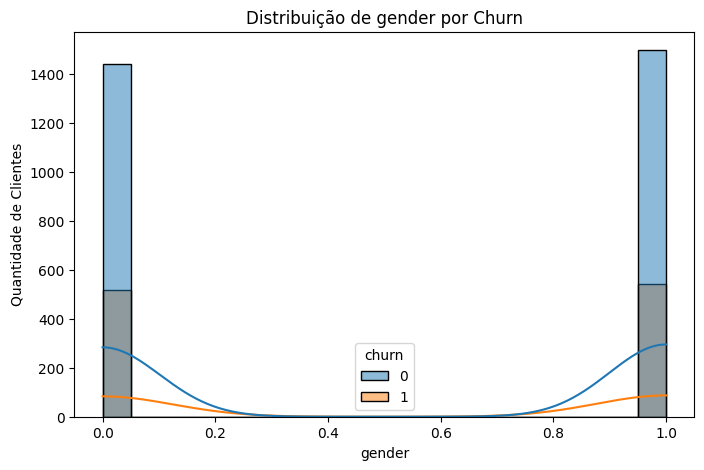

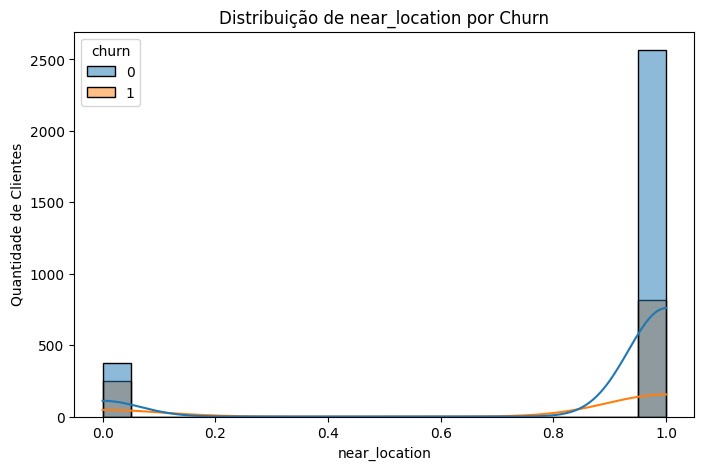

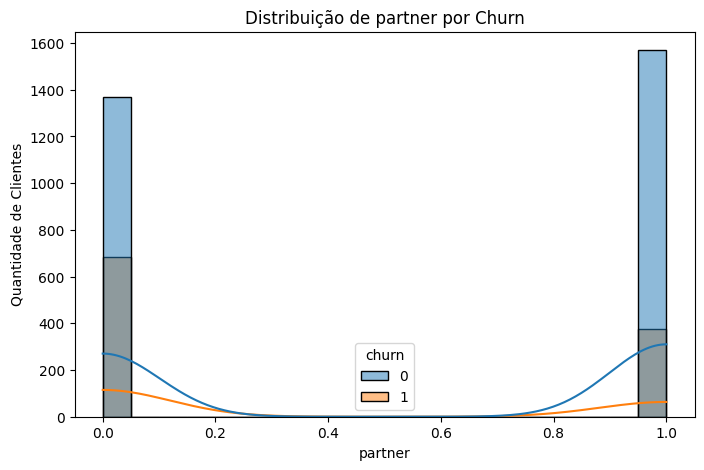

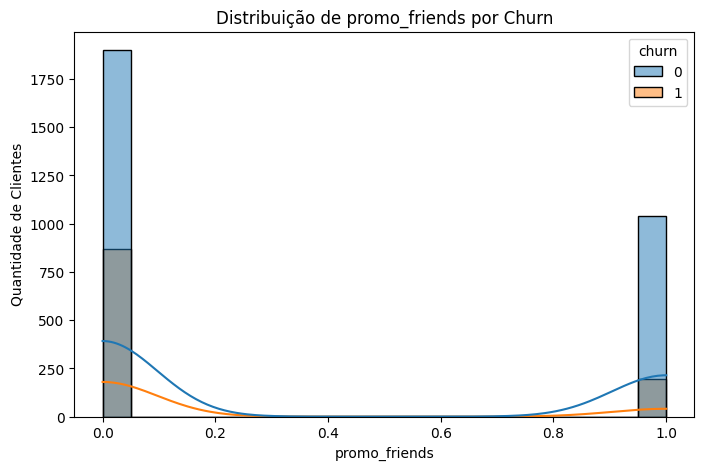

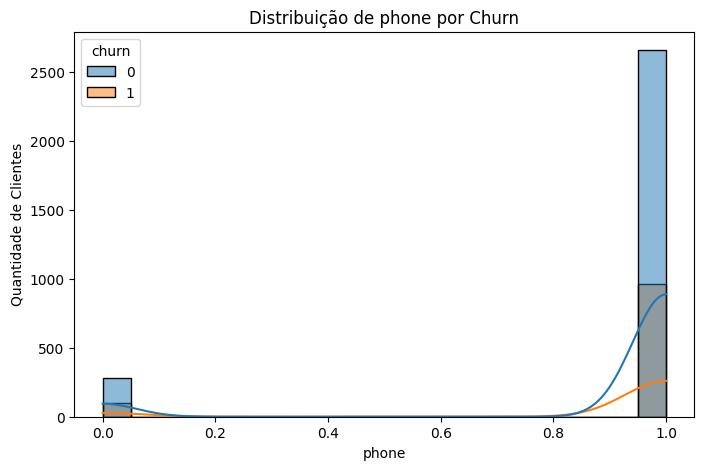

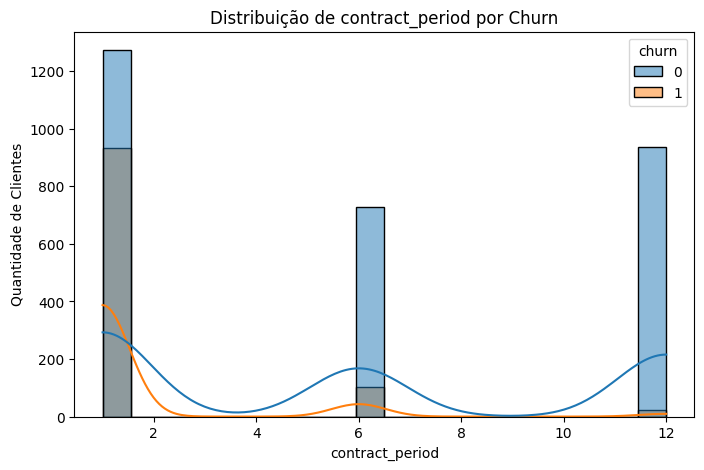

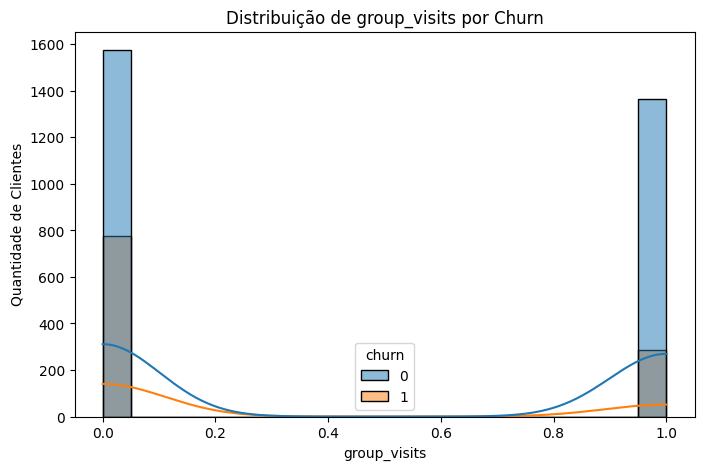

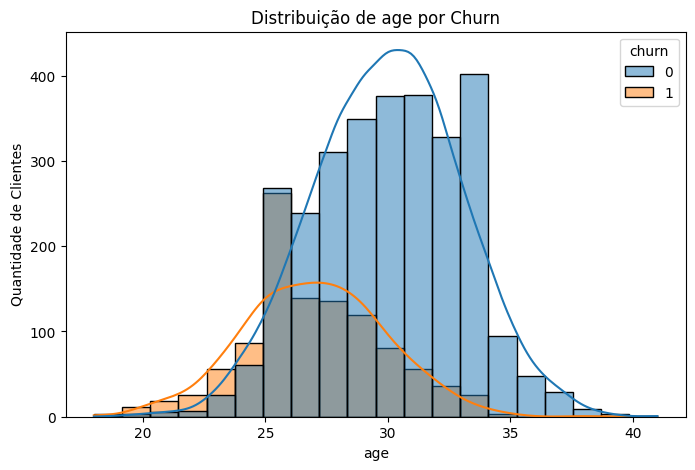

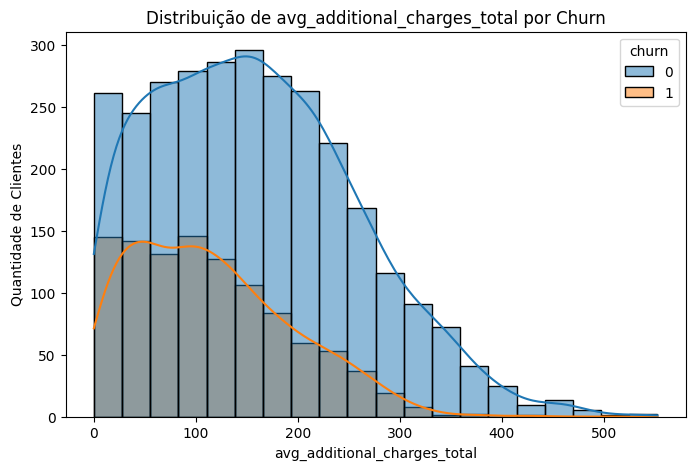

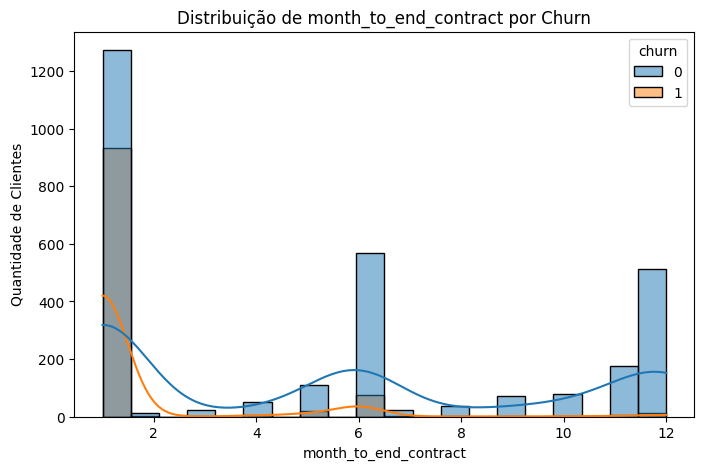

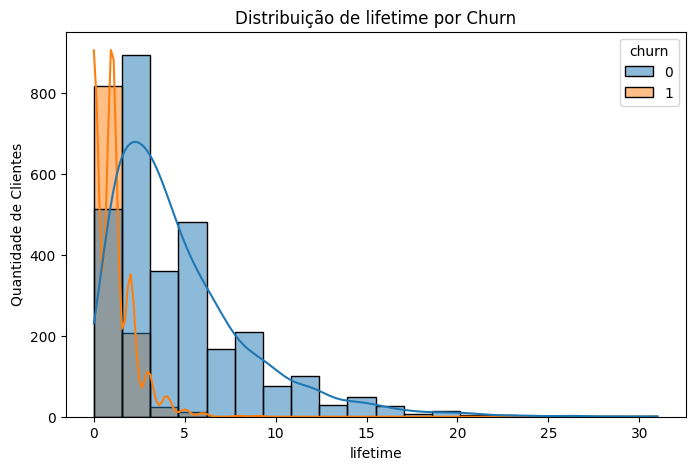

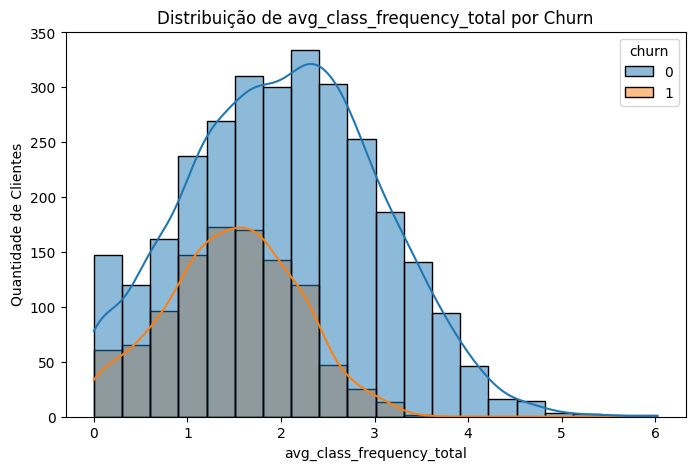

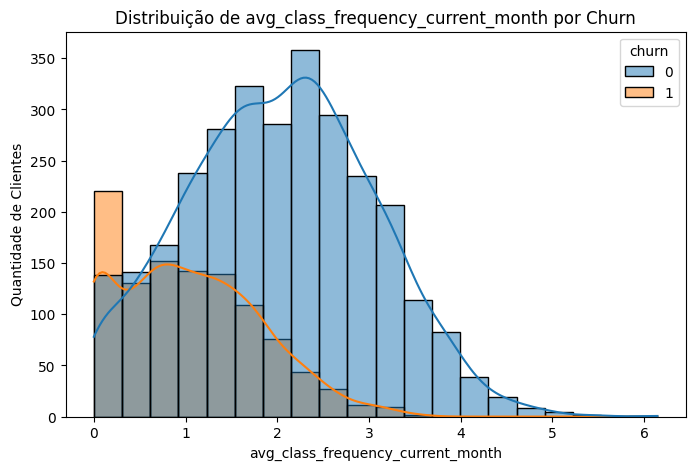

In [13]:
# Criando histogramas de barra e distribuições de características para aqueles que saíram (rotatividade) e aqueles que ficaram
features = gym_churn_us.drop('churn', axis=1).columns

for feature in features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=gym_churn_us,
        x=feature,
        hue='churn',
        kde=True,
        bins=20
    )
    
    plt.title(f'Distribuição de {feature} por Churn')
    plt.xlabel(feature)
    plt.ylabel('Quantidade de Clientes')
    plt.show()

Foram construídos histogramas de barras para comparar as características dos clientes que permaneceram na academia (churn = 0) com aqueles que saíram (churn = 1).

Os gráficos mostram diferenças principalmente nas variáveis relacionadas ao comportamento e ao envolvimento dos clientes com a academia. Os clientes que permaneceram tendem a apresentar maior frequência de visitas, maior tempo de permanência, contratos mais longos e maior participação em atividades em grupo.

Entre os clientes que saíram, observa-se maior concentração de valores baixos para frequência de visitas, tempo de permanência e duração dos contratos. Esses padrões sugerem que o nível de engajamento e o tempo de relacionamento com a academia podem estar relacionados à rotatividade.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa escolha usar `histplot` com `hue='churn'` para comparar as distribuições de cada característica entre quem ficou e quem saiu. A leitura de que a concentração em valores baixos de frequência, lifetime e duração de contrato aparece mais entre quem cancelou está alinhada com o que você já tinha visto nas médias por grupo.
</div>

In [14]:
# Construindo a matriz de correlação
cm = gym_churn_us.corr()

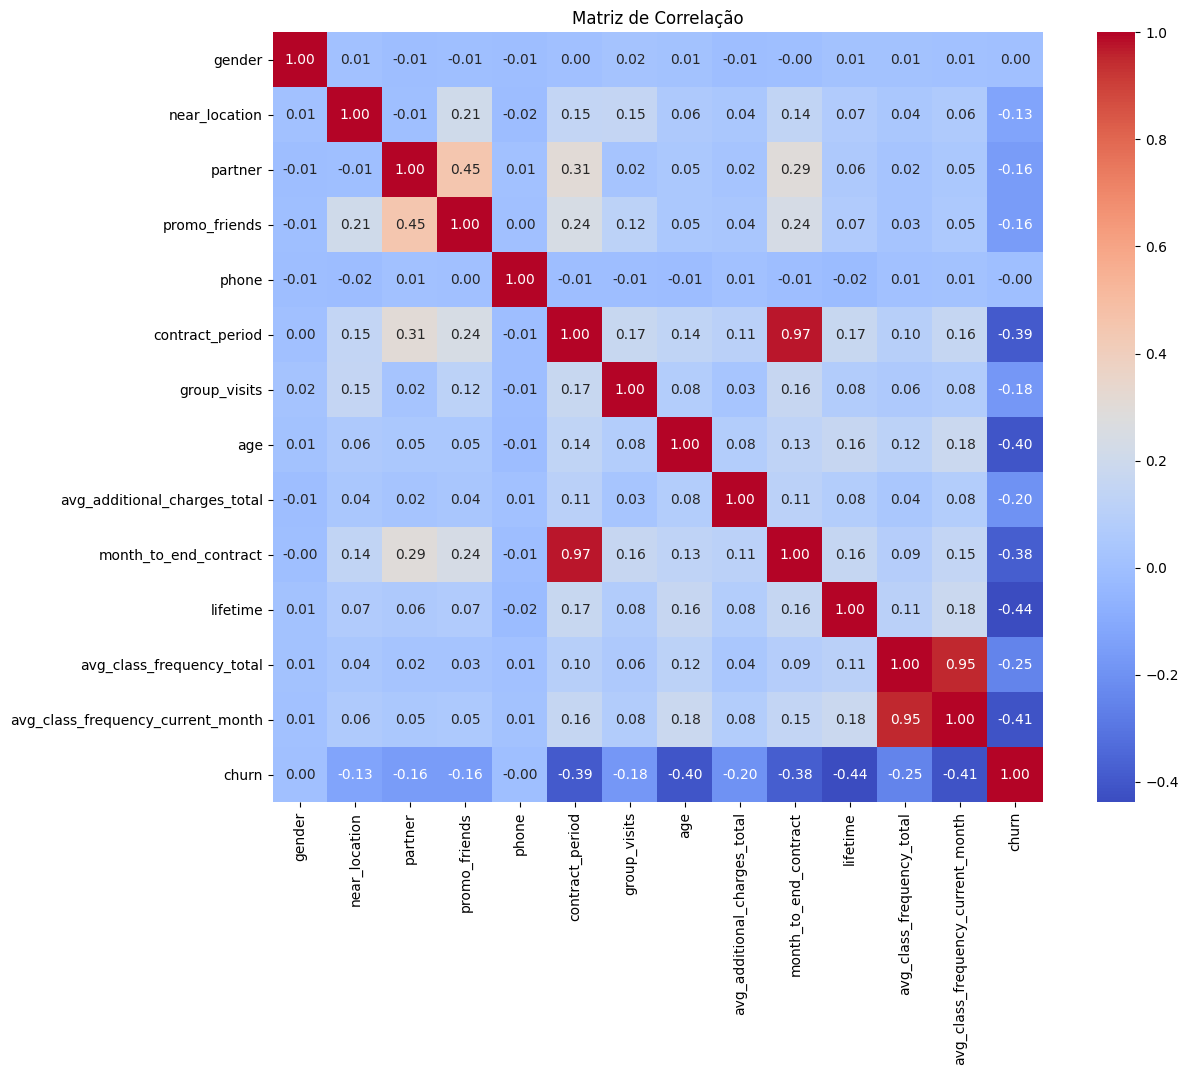

In [15]:
# Exibindo a matriz de correlação
plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    square=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação mostra a relação entre as características dos clientes e a variável objetivo churn. Dessa forma, +1 indica uma correlação positiva perfeita, valores próximos de +1 indicam uma correlação positiva forte, ou seja, as variáveis tendem a aumentar juntas. Além disso, 0 indica ausência de correlação linear entre as variáveis, valores próximos de -1 indicam uma correlação negativa forte, em que o aumento de uma variável está associado à diminuição da outra e -1 indica uma correlação negativa perfeita, quando as variáveis apresentam uma relação linear inversa completa.

De modo geral, não foram identificadas correlações extremamente fortes entre a maioria das características, porém algumas relações se destacam.

Em relação à variável churn, as maiores correlações negativas foram observadas com:

- lifetime: -0.44, indicando que clientes com maior tempo de relacionamento com a academia tendem a apresentar menor probabilidade de rotatividade.
- avg_class_frequency_current_month: -0.41, mostrando que clientes que frequentam mais a academia no mês atual tendem a permanecer mais (menor rotatividade).
- age: -0.40, indicando uma tendência de clientes mais velhos apresentarem menor rotatividade.
- contract_period: -0.39, sugerindo que contratos de maior duração estão associados a uma menor taxa de rotatividade.
- month_to_end_contract: -0.38, indicando que clientes com mais meses restantes de contrato tendem a apresentar menor rotatividade.
- avg_class_frequency_total: -0.25, indicando uma relação negativa, embora mais fraca, entre a frequência média de visitas ao longo do relacionamento e a rotatividade.

Também foram observadas correlações negativas mais moderadas entre churn e algumas outras características:

- group_visits: -0.18
- partner: -0.16
- promo_friends: -0.16
- near_location: -0.13

Isso indica que clientes que participam de atividades em grupo, são funcionários de empresas parceiras, vieram por indicação de amigos ou moram/trabalham perto da academia tendem a apresentar menor rotatividade.

Por outro lado, gender apresentou correlação praticamente nula com churn (0.00) e phone também apresentou correlação praticamente nula (-0.00), indicando que essas características não apresentam uma relação linear relevante com a rotatividade.

Também é importante observar algumas correlações fortes entre as próprias características. A maior delas ocorre entre contract_period e month_to_end_contract, com correlação de 0.97. Isso é esperado, pois contratos mais longos normalmente possuem mais meses restantes até o vencimento. Outra correlação forte ocorre entre avg_class_frequency_total e avg_class_frequency_current_month, com valor de 0.95, indicando que a frequência média histórica está fortemente relacionada à frequência do mês atual. Essas correlações fortes entre características devem ser consideradas na construção dos modelos.

De forma geral, os fatores mais relacionados à redução do churn foram lifetime (-0.44), avg_class_frequency_current_month (-0.41), age (-0.40), contract_period (-0.39) e month_to_end_contract (-0.38). Isso sugere que clientes mais antigos, que frequentam mais a academia e possuem contratos mais longos ou com mais tempo restante, tendem a permanecer mais. Além de que quanto maior a idade do cliente, menor tende a ser a probabilidade de rotatividade (churn).

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Interpretação da matriz de correlação muito completa. Você não só listou as correlações mais fortes com `churn` (lifetime -0.44, avg_class_frequency_current_month -0.41, age -0.40, contract_period -0.39), como também identificou os dois pares de variáveis mais correlacionadas entre si: `contract_period` e `month_to_end_contract` (0.97), e `avg_class_frequency_total` e `avg_class_frequency_current_month` (0.95). Reconhecer essa multicolinearidade é exatamente o tipo de cuidado que se espera antes de interpretar coeficientes de um modelo de regressão logística.
</div>

# Passo 3. Construindo um modelo para predizer a rotatividade de clientes

In [16]:
# Dividindo os dados de treinamento e validação em dois conjuntos
X = gym_churn_us.drop('churn', axis=1)
y = gym_churn_us['churn']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=12345)

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

A divisão treino/validação está correta (80/20). Uma sugestão de refinamento: como a variável `churn` não é perfeitamente balanceada (≈26.5% de casos positivos), vale usar o parâmetro `stratify=y` para garantir que essa proporção se mantenha tanto no treino quanto na validação. Isso evita que, por acaso, um dos conjuntos fique com uma proporção de churn bem diferente da real.

```python
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y
)
```
Referência: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
</div>

In [17]:
# Criando e treinando o modelo no conjunto com o método de regressão logística
logistic_model = LogisticRegression(random_state=12345, max_iter=1000)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=12345)

In [18]:
# Criando e treinando o modelo no conjunto com o método de floresta aleatória
random_forest_model = RandomForestClassifier(random_state=12345)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=12345)

In [19]:
# Fazendo previsões no conjunto de validação
logistic_predictions = logistic_model.predict(X_valid)
random_forest_predictions = random_forest_model.predict(X_valid)

# Avaliando a regressão logística
print('Regressão logística:')
print('Acurácia:', accuracy_score(y_valid, logistic_predictions))
print('Precisão:', precision_score(y_valid, logistic_predictions))
print('Sensibilidade:', recall_score(y_valid, logistic_predictions))

print()

# Avaliando a floresta aleatória
print('Floresta aleatória:')
print('Acurácia:', accuracy_score(y_valid, random_forest_predictions))
print('Precisão:', precision_score(y_valid, random_forest_predictions))
print('Sensibilidade:', recall_score(y_valid, random_forest_predictions))


Regressão logística:
Acurácia: 0.91875
Precisão: 0.865979381443299
Sensibilidade: 0.8115942028985508

Floresta aleatória:
Acurácia: 0.90125
Precisão: 0.8404255319148937
Sensibilidade: 0.7632850241545893


Após o treinamento e a avaliação dos modelos de regressão logística e floresta aleatória, utilizando o conjunto de validação, foi possível comparar o desempenho de ambos por meio das métricas de acurácia, precisão e sensibilidade.

A regressão logística apresentou os melhores resultados nas três métricas avaliadas. O modelo alcançou 91.88% de acurácia, indicando que classificou corretamente aproximadamente 92% dos clientes do conjunto de validação. A precisão foi de 86.60%, o que significa que, entre os clientes classificados pelo modelo como possíveis casos de churn, aproximadamente 87% realmente pertenciam à classe de churn. Já a sensibilidade foi de 81.16%, indicando que o modelo conseguiu identificar aproximadamente 81% dos clientes que realmente cancelaram ou deixaram de utilizar o serviço.

Por outro lado, a floresta aleatória apresentou 90.13% de acurácia, 84.04% de precisão e 76.33% de sensibilidade. Embora também tenha apresentado um bom desempenho, seus resultados foram inferiores aos da regressão logística em todas as métricas analisadas.

A diferença entre os modelos foi em torno de 1.75 ponto percentual na acurácia (91.88% contra 90.13%), em torno de 2.56 pontos percentuais na precisão (86.60% contra 84.04%) e em torno de 4.83 pontos percentuais na sensibilidade (81.16% contra 76.33%). A maior diferença ocorreu na sensibilidade, métrica especialmente relevante para o problema de churn, pois representa a capacidade do modelo de identificar corretamente os clientes que realmente irão sair.

Dessa forma, a regressão logística foi o modelo que apresentou o melhor desempenho geral. Além de possuir a maior acurácia e precisão, apresentou uma sensibilidade significativamente superior à floresta aleatória, conseguindo identificar uma parcela maior dos clientes que realmente apresentaram churn.

Portanto, considerando os resultados obtidos no conjunto de validação, a regressão logística é o modelo mais adequado entre os dois para este problema, pois apresentou desempenho superior e maior capacidade de identificar clientes em risco de churn.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Comparação muito bem feita entre os dois modelos, com leitura correta das três métricas. A regressão logística superou a floresta aleatória em acurácia (91.88% vs 90.13%), precisão (86.60% vs 84.04%) e principalmente em sensibilidade (81.16% vs 76.33%) — e você identificou corretamente que a sensibilidade é a métrica mais relevante aqui, já que é ela que mede a capacidade do modelo de identificar quem realmente vai sair. A escolha final pela regressão logística está bem fundamentada nos números.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Um ponto que ficou faltando: interpretar os coeficientes da regressão logística (ou a importância das variáveis da floresta aleatória) para conectar o modelo preditivo com os fatores de churn que você já tinha identificado na matriz de correlação. Isso é especialmente relevante porque `contract_period` e `month_to_end_contract` (que você já apontou como fortemente correlacionadas, 0.97) entraram juntas no modelo sem nenhum tratamento — quando duas variáveis são muito correlacionadas, os coeficientes da regressão logística podem ficar instáveis ou difíceis de interpretar isoladamente, mesmo que a previsão final continue boa. Vale extrair os coeficientes e comparar com o que a matriz de correlação já indicava:

```python
import pandas as pd
coefs = pd.Series(logistic_model.coef_[0], index=X.columns).sort_values()
coefs.plot(kind='barh', title='Coeficientes - Regressão Logística')
```
Não é obrigatório remover nenhuma das duas colunas, mas comentar esse efeito (ou testar o modelo sem uma delas) deixaria a análise ainda mais redonda.

Referência: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
</div>

# Passo 4. Criando agrupamentos de clientes

In [20]:
# Padronizando os dados
numeric_columns = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'contract_period', 'group_visits', 'age', 'lifetime', 'month_to_end_contract', 'avg_class_frequency_total', 'avg_class_frequency_current_month', 'avg_additional_charges_total']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(gym_churn_us[numeric_columns])

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Ponto importante: `numeric_columns` não inclui a coluna `churn`, ou seja, a padronização e, na sequência, o próprio agrupamento são feitos sem usar a variável que queremos prever. Isso evita um erro clássico dessa etapa (vazamento de dados/data leakage), em que o algoritmo de clustering "aprenderia" a resposta em vez de descobrir grupos de forma genuinamente não supervisionada.
</div>

In [21]:
# Construindo a matriz das distâncias e o agrupamento hierárquico
linked = linkage(X_scaled, method='ward')

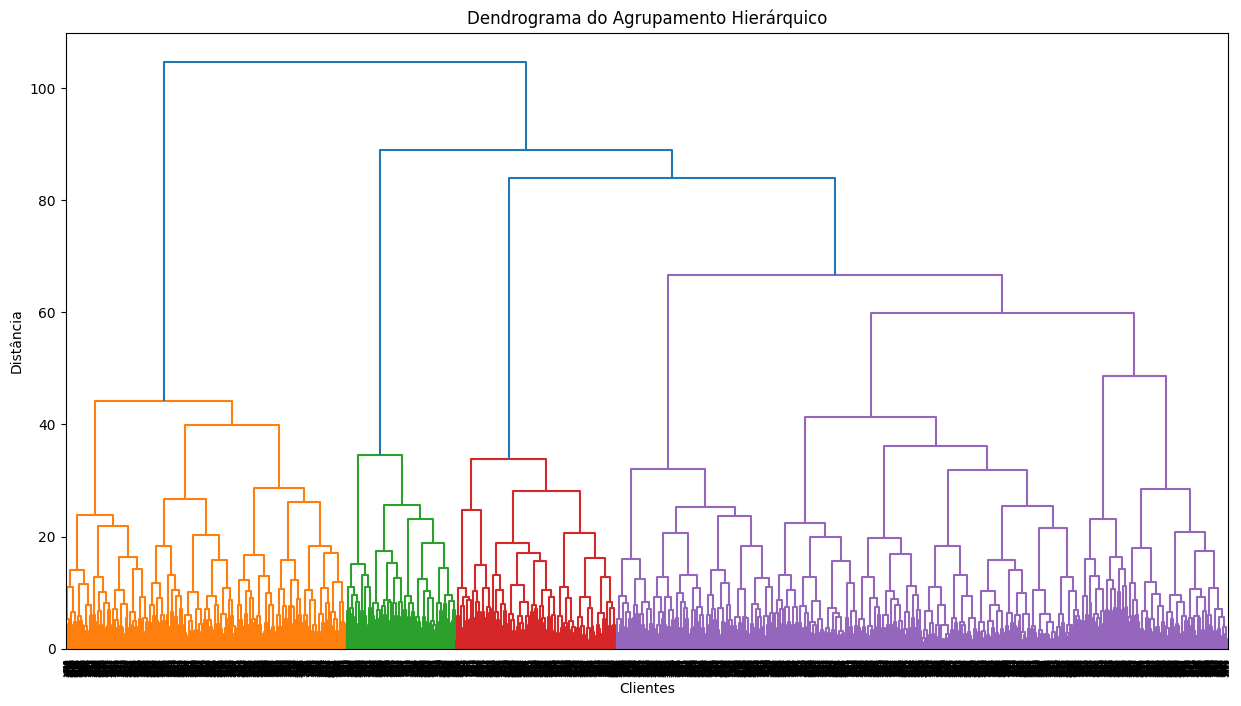

In [22]:
# Construindo o dendrograma
plt.figure(figsize=(15, 8))
dendrogram(linked)

plt.title('Dendrograma do Agrupamento Hierárquico')
plt.xlabel('Clientes')
plt.ylabel('Distância')
plt.show()

Ao analisar o dendrograma, podemos estimar a formação de 4 agrupamentos. Para chegar a essa estimativa, é possível imaginar um corte horizontal em uma altura, como por exemplo a 75, em que os grandes grupos ainda estejam separados, antes das ligações realizadas em distâncias maiores. Nesse corte (75), observamos quatro conjuntos principais de ramos, destacados pelas cores laranja, verde, vermelho e roxo. Cada cor representa visualmente um agrupamento de clientes com características mais semelhantes entre si. Portanto, o corte do dendrograma permite identificar aproximadamente 4 grupos, enquanto as cores facilitam a visualização e diferenciação desses agrupamentos. Vale destacar que não é a cor que determina os grupos, o raciocínio é o contrário: o corte escolhido no dendrograma determina a quantidade de grupos, e as cores ajudam a visualizá-los.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Leitura do dendrograma bem explicada — usar um corte horizontal (na altura 75) para contar quantos ramos principais ele atravessa é exatamente a lógica certa para estimar o número de grupos, e você deixou claro que é o corte que define os grupos, não o contrário. A estimativa de 4 grupos pelo dendrograma é uma leitura exploratória válida; como você já tinha adiantado na introdução do projeto, o K-Means final usa 5 clusters conforme pedido no enunciado, então não há contradição, só duas etapas com propósitos diferentes.
</div>

In [23]:
# Criando o modelo K-Means com 5 agrupamentos
km = KMeans(n_clusters=5, random_state=0)

In [24]:
# Treinando o modelo e atribuindo cada cliente a um agrupamento
labels = km.fit_predict(X_scaled)

In [25]:
# Adicionando os agrupamentos ao DataFrame
gym_churn_us['cluster_km'] = labels
print(gym_churn_us.head())

   gender  near_location  partner  promo_friends  phone  contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   group_visits  age  avg_additional_charges_total  month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   lifetime  avg_class_frequency_total  avg_class_frequency_current_month  \
0  

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Fluxo correto: `fit_predict` foi aplicado sobre `X_scaled` (dados padronizados), e os rótulos resultantes foram adicionados de volta ao DataFrame original (com as escalas originais). Isso é importante porque as próximas análises de perfil por cluster ficam muito mais interpretáveis em unidades reais (meses, valores em moeda, etc.) do que se estivessem na escala padronizada.
</div>

In [26]:
# Calculando a média de cada característica dentro de cada cluster
gym_churn_us.groupby('cluster_km')[numeric_columns].mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,lifetime,month_to_end_contract,avg_class_frequency_total,avg_class_frequency_current_month,avg_additional_charges_total
cluster_km,,,,,,,,,,,,,
0,0.502970,0.959406,0.783168,0.574257,1.000000,10.889109,0.542574,29.982178,4.736634,9.954455,1.982055,1.974789,160.761016
1,0.522078,0.862338,0.470130,0.306494,0.000000,4.787013,0.425974,29.301299,3.924675,4.475325,1.847220,1.716369,143.957664
2,0.495050,0.000000,0.463366,0.079208,1.000000,2.352475,0.215842,28.477228,2.809901,2.198020,1.660461,1.477324,135.457501
3,0.485737,1.000000,0.350238,0.240095,1.000000,1.948494,0.341521,28.167987,2.440571,1.856577,1.247634,1.012983,131.622204
4,0.559666,0.976134,0.356802,0.230310,0.998807,2.669451,0.473747,30.125298,4.898568,2.459427,2.852002,2.850161,161.657905


A análise das médias das características dos clientes nos cinco agrupamentos revelou diferenças importantes entre os clusters. O cluster 0 apresenta a maior duração média de contrato, com média de 10.89 meses, além de uma frequência média de 1.97 visita no mês atual e gastos adicionais médios de 160.76. Também se destaca pelo fato de 100% dos clientes possuírem telefone cadastrado.

O cluster 1 apresenta um perfil intermediário, com duração média de contrato de 4.79 meses, lifetime de 3.92 meses e frequência média atual de 1.72. Uma característica bastante marcante é que 0% dos clientes possuem telefone cadastrado.

O cluster 2 apresenta características de baixo engajamento. Nenhum dos clientes (0%) mora próximo à academia, apenas 7.92% aderiram por promoção de amigos e a duração média dos contratos é de apenas 2.35 meses. O lifetime médio é de 2.81 meses e a frequência média no mês atual é de 1.48.

O cluster 3 é o grupo que apresenta os menores indicadores de relacionamento com a academia. A duração média dos contratos é de apenas 1.95 mês, o lifetime médio é de 2.44 meses e a frequência média no mês atual é de apenas 1.01. Além disso, o gasto adicional médio é o menor entre os grupos, com 131.62. Apesar disso, 100% dos clientes desse cluster moram perto da academia.

Por fim, o cluster 4 apresenta o perfil mais engajado em relação à frequência de utilização. Possui o maior lifetime médio (4.90 meses), a maior frequência média total (2.85) e também a maior frequência média no mês atual (2.85). Além disso, apresenta o maior gasto adicional médio, de 161.66.

De modo geral, os clusters 0 e 4 apresentam clientes mais ativos e com maior relacionamento com a academia, enquanto os clusters 2 e 3 apresentam características associadas a menor engajamento, como contratos mais curtos, menor lifetime e menor frequência de visitas. O cluster 3 merece atenção especial, pois apresenta a menor duração média de contrato, menor lifetime, menor frequência atual e menor valor em relação aos gastos adicionais, mesmo com 100% dos clientes morando perto da academia.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Perfil de clusters muito bem construído e descrito grupo a grupo. Você não ficou só nos números: deu sentido a cada cluster (o cluster 0 com contratos de quase 11 meses e 100% com telefone cadastrado, o cluster 3 com o pior conjunto de indicadores — contrato de 1.95 mês, lifetime de 2.44 meses e a menor frequência do mês atual). Essa é exatamente a diferença entre mostrar 'Cluster 0, 1, 2' e explicar quem são esses grupos, que é o que se espera nessa etapa.
</div>

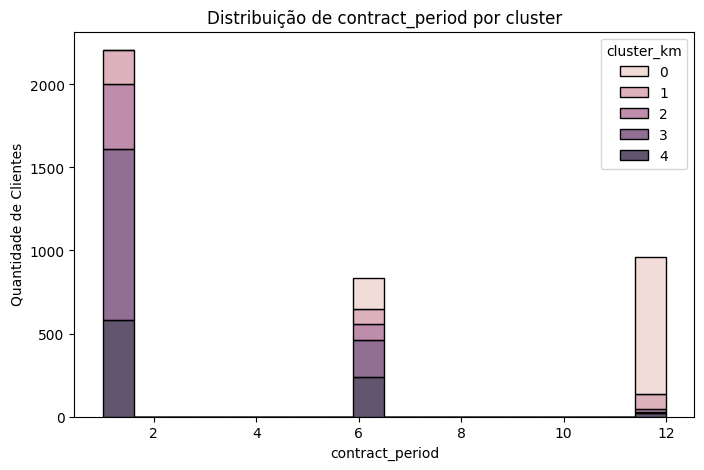

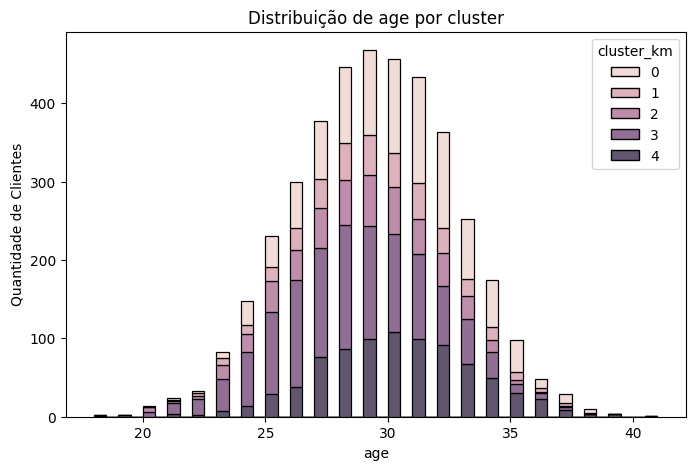

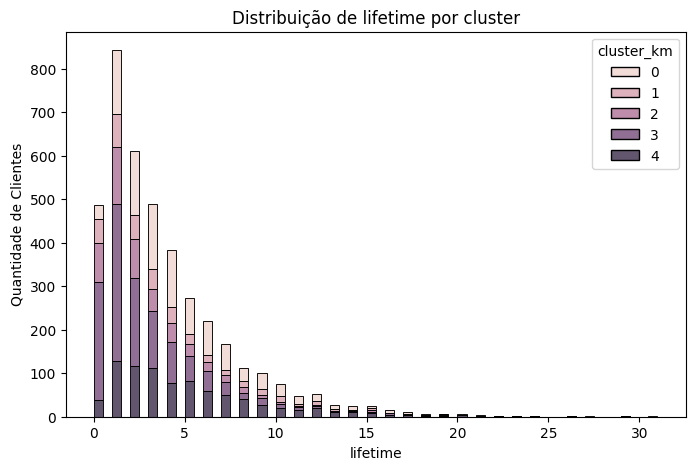

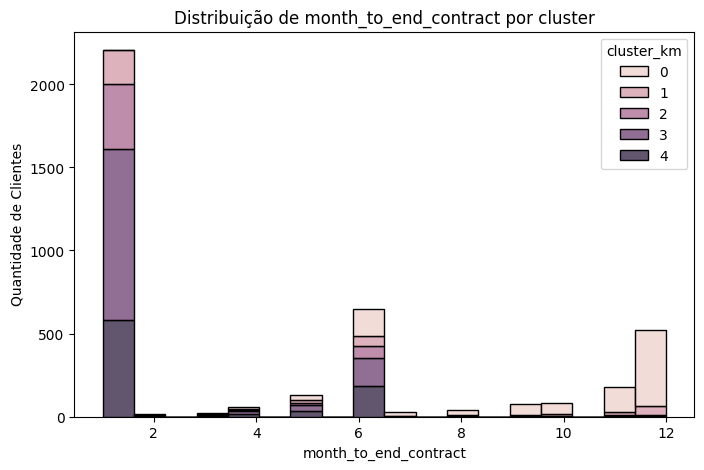

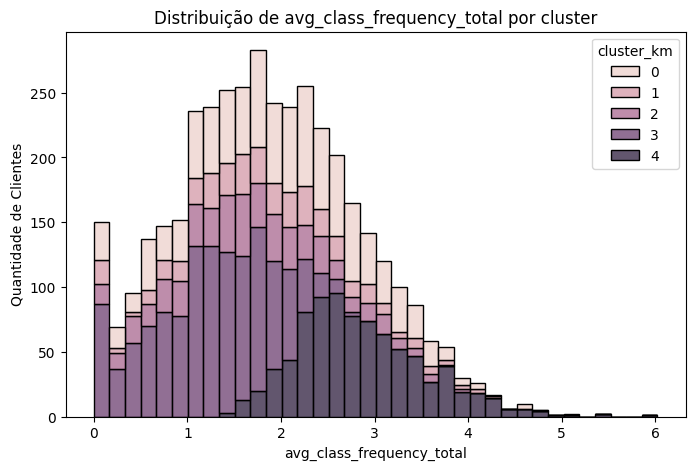

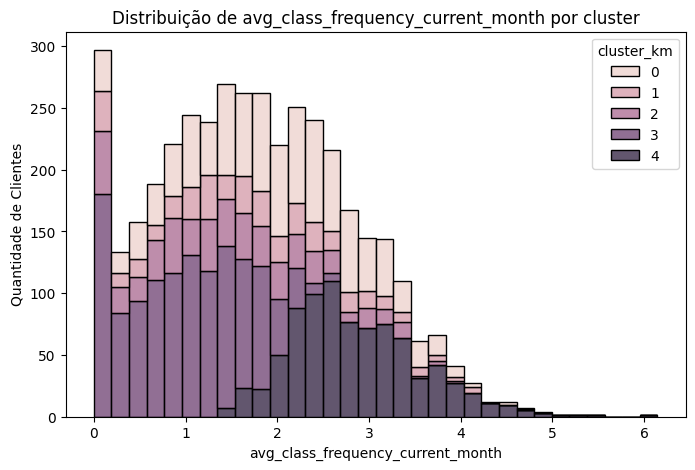

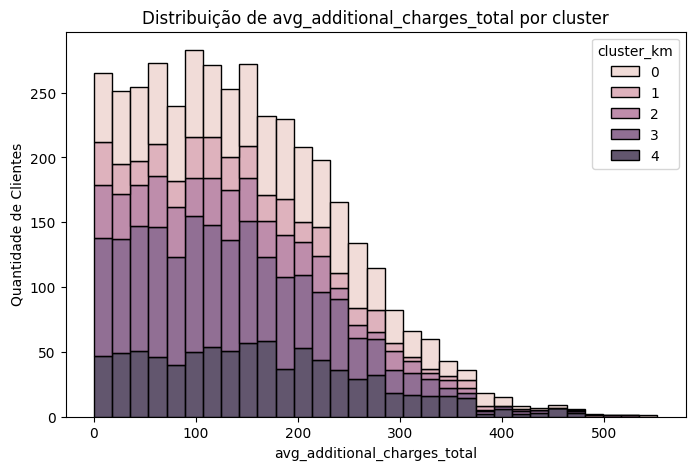

In [27]:
# Criando histogramas de distribuição das características numéricas para cada um dos 5 clusters
continuous_columns = [
    'contract_period',
    'age',
    'lifetime',
    'month_to_end_contract',
    'avg_class_frequency_total',
    'avg_class_frequency_current_month',
    'avg_additional_charges_total'
]

for feature in continuous_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=gym_churn_us,
        x=feature,
        hue='cluster_km',
        multiple='stack'
    )
    
    plt.title(f'Distribuição de {feature} por cluster')
    plt.xlabel(feature)
    plt.ylabel('Quantidade de Clientes')
    plt.show()

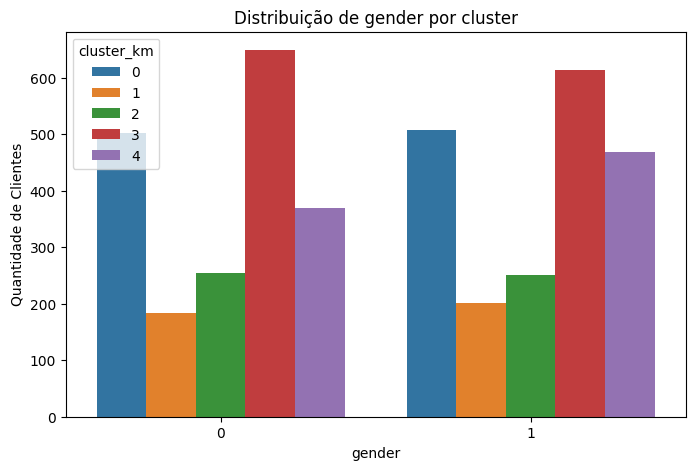

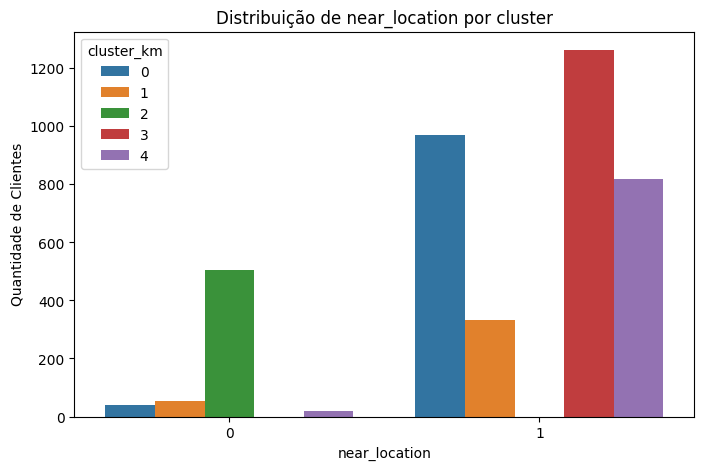

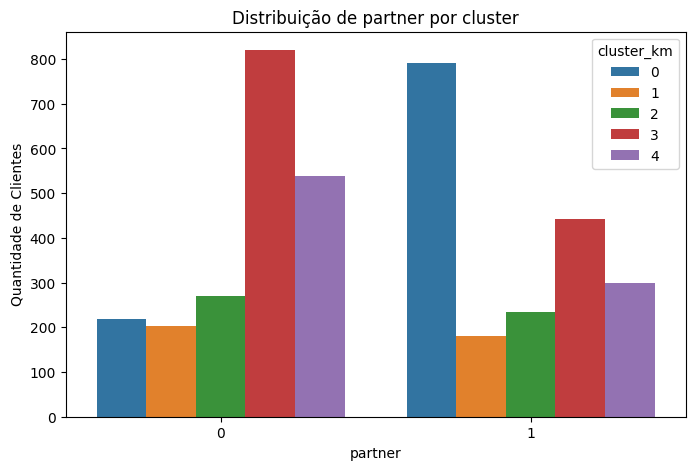

In [ ]:
# Criando gráficos de distribuição das características binárias para cada um dos 5 clusters
binary_columns = [
    'gender',
    'near_location',
    'partner',
    'promo_friends',
    'phone',
    'group_visits'
]

for feature in binary_columns:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(
        data=gym_churn_us,
        x=feature,
        hue='cluster_km'
    )
    
    plt.title(f'Distribuição de {feature} por cluster')
    plt.xlabel(feature)
    plt.ylabel('Quantidade de Clientes')
    plt.show()

A análise dos gráficos de distribuição mostra que os agrupamentos apresentam diferenças claras na concentração dos valores das características, confirmando que o K-Means identificou perfis distintos de clientes. Nas variáveis relacionadas à utilização da academia, como lifetime, contract_period e frequência de visitas, é possível observar uma maior concentração de valores baixos nos clusters 2 e 3, enquanto os clusters 0 e 4 apresentam maior concentração em valores mais altos.

O cluster 3 se destaca pela concentração de clientes com menor lifetime, menor duração de contrato e menor frequência de visitas. Já o cluster 4 apresenta uma distribuição mais concentrada em valores elevados de frequência de utilização, lifetime e gastos adicionais, caracterizando clientes mais ativos. O cluster 0 também apresenta valores elevados de duração de contrato e boa frequência de utilização.

Nas variáveis binárias, os gráficos de barras evidenciam diferenças ainda mais marcantes entre os grupos. O cluster 2, por exemplo, apresenta 0% de clientes morando próximo à academia, enquanto no cluster 3 esse valor é de 100%. Também há uma diferença muito clara na variável phone: 100% dos clientes do cluster 0 possuem telefone cadastrado, enquanto no cluster 1 essa proporção é de 0%.

Ao analisar os gráficos de distribuição de contract_period e lifetime, observa-se que existe alguma sobreposição entre os clusters, principalmente entre grupos com médias próximas. Os clusters 2 e 3 apresentam distribuições mais concentradas em valores baixos de lifetime, com médias de 2.81 e 2.44 meses, respectivamente, enquanto os clusters 0 e 4 apresentam valores mais altos, de 4.74 e 4.90 meses. Em contract_period, o cluster 0 se destaca pela maior duração média, de 10.89 meses, apresentando uma diferença mais evidente em relação aos demais grupos. Portanto, embora os clusters não sejam completamente separados nessas características, existem concentrações diferentes de valores que ajudam a distinguir os perfis dos clientes.

De forma geral, os gráficos reforçam que os clusters não são apenas diferentes em suas médias, mas também apresentam distribuições e concentrações diferentes nas características dos clientes. Os clusters 0 e 4 concentram clientes com maior utilização e relacionamento com a academia, enquanto os clusters 2 e 3 concentram clientes com características de menor engajamento. Portanto, a análise das distribuições confirma a existência de perfis de clientes bem diferenciados entre os cinco agrupamentos.

Pensando de forma prática para o negócio da academia, o cluster 3 seria o grupo que merece maior atenção e uma ação de retenção mais urgente. A principal característica utilizada para justificar essa escolha é o contract_period, que apresenta a menor duração média entre os cinco grupos, de apenas 1.95 mês. Esse resultado é reforçado pelo menor lifetime médio (2.44 meses), pela menor frequência de visitas no mês atual (1.01) e pelo menor gasto adicional médio (131.62). Além disso, mesmo com 100% dos clientes morando próximo à academia, esses clientes apresentam baixo nível de utilização. Dessa forma, seria interessante criar ações específicas de retenção para esse grupo, como campanhas de incentivo à frequência, benefícios para renovação e ofertas de planos mais longos.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Muito boa análise das distribuições por cluster, e você foi além: já adiantou aqui a resposta de negócio de qual grupo merece a ação de retenção mais urgente. A justificativa é sólida e usa vários indicadores juntos, não só um número isolado: o cluster 3 tem o menor `contract_period` (1.95 mês), o menor `lifetime` (2.44 meses), a menor frequência no mês atual (1.01) e o menor gasto adicional médio (131.62) entre os cinco grupos. Cruzar várias características para justificar a priorização, em vez de olhar uma métrica isolada, é exatamente o tipo de leitura que se espera nessa etapa.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

A célula anterior, que gera os gráficos de distribuição das variáveis binárias por cluster, está sem número de execução e mostra só 3 dos 6 gráficos esperados (um para cada variável em `binary_columns`), o que sugere que a execução foi interrompida antes de terminar o laço. Vale rodar o notebook inteiro do início (Kernel > Restart & Run All) antes da entrega final, para garantir que todas as células mostrem as saídas completas.
</div>

In [ ]:
# Calculando a taxa de rotatividade para cada agrupamento
churn_rate = gym_churn_us.groupby('cluster_km')['churn'].mean()
print(churn_rate)

A análise da taxa de rotatividade (churn) mostra diferenças significativas entre os cinco clusters. O cluster 3 apresenta a maior taxa de rotatividade, em torno de 51.43%, sendo o grupo mais propenso a deixar a academia e, portanto, o que merece maior atenção nas estratégias de retenção. O cluster 2 também apresenta alta rotatividade, em torno de 44.36%, representando outro grupo de risco.

Em contrapartida, os clusters 0 e 4 apresentam as menores taxas de rotatividade, em torno de 2.77% e 6.80%, respectivamente, sendo considerados os grupos mais leais à academia. O cluster 1 apresenta uma taxa intermediária em torno de 26.75%.

Dessa forma, os clusters 3 e 2 são os mais propensos a sair, enquanto os clusters 0 e 4 são os mais leais. Esses resultados são importantes para direcionar as estratégias de retenção, priorizando os clientes dos clusters 3 e 2, que apresentam maior risco de abandono.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa leitura da taxa de churn por cluster. Pelos valores que você reportou, os clusters 3 e 2 concentram o maior risco de saída, enquanto os clusters 0 e 4 são os mais fiéis — e essa priorização é coerente com o perfil que você já tinha traçado para cada grupo (contratos mais curtos e menor engajamento nos clusters de maior risco). Essa tabela conecta diretamente o trabalho de clustering com uma métrica de negócio acionável, e é a base certa para priorizar as ações de retenção que vêm a seguir.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Um detalhe técnico: a célula que calcula o `churn_rate` por cluster está sem número de execução e sem saída registrada no notebook entregue, mesmo os valores aparecendo aqui no texto logo depois. Provavelmente ela foi executada em algum momento anterior e o notebook foi salvo antes de rodar essa célula de novo. Antes da entrega final, vale rodar tudo em sequência (Kernel > Restart & Run All) para garantir que o notebook entregue mostre, de fato, a saída de cada célula que ele referencia.
</div>

# Passo 5. Conclusões e Recomendações

A análise dos agrupamentos mostrou que os clientes possuem perfis e níveis de risco de saída diferentes, portanto, uma estratégia de retenção deve ser segmentada.

1. Priorizar os clusters com maior risco de saída

Os clusters 3 e 2 devem receber maior atenção, pois apresentam as maiores taxas de rotatividade, de 51.43% e 44.36%, respectivamente.

Ações de marketing:

- Criar campanhas específicas de retenção para esses clientes;
- Oferecer benefícios ou descontos para renovação;
- Enviar mensagens personalizadas para clientes com baixa frequência;
- Criar incentivos para aumentar a frequência de visitas.

2. Trabalhar preventivamente com o cluster 1

O cluster 1 apresenta uma taxa de rotatividade intermediária de 26.75%, indicando um nível de risco menor que os clusters 2 e 3, mas ainda relevante. Por isso, esse grupo pode ser trabalhado de forma preventiva, buscando evitar que os clientes evoluam para um perfil de maior risco.

Ações de marketing:

- Monitorar a frequência de visitas e identificar clientes que estejam reduzindo sua utilização;
- Enviar lembretes e mensagens personalizadas para estimular a frequência;
- Oferecer benefícios para renovação antecipada do contrato;
- Criar campanhas de engajamento e relacionamento com esses clientes.

3. Estimular a frequência dos clientes pouco engajados

O cluster 3 apresenta frequência média de apenas 1.01 visita no mês atual, além de lifetime de 2.44 meses e contrato médio de apenas 1.95 mês.

Ações de marketing:

- Enviar notificações quando o cliente ficar vários dias sem frequentar a academia;
- Criar desafios de frequência;
- Oferecer recompensas após determinado número de visitas;
- Incentivar a renovação antes do término do contrato.

4. Manter e fortalecer os clientes mais leais

Os clusters 0 e 4 apresentam as menores taxas de churn, de apenas 2.77% e 6.80%, respectivamente. Portanto, esses clientes já apresentam maior fidelidade e devem ser tratados também como uma oportunidade de fidelização e aumento de receita.

Ações de marketing:

- Oferecer benefícios exclusivos;
- Criar programas de fidelidade;
- Oferecer serviços ou produtos adicionais;
- Incentivar indicações de amigos.

5. Utilizar estratégias diferentes para cada perfil

Os resultados mostram que uma única estratégia para todos os clientes não seria a mais adequada. A academia pode utilizar os clusters para criar campanhas personalizadas de acordo com o comportamento de cada grupo.

Em resumo: a prioridade deve ser reduzir a rotatividade dos clusters 3 e 2, por apresentarem maior risco de saída, enquanto os clusters 0 e 4 devem receber ações de fidelização e incentivo ao consumo de serviços adicionais. A segmentação permite direcionar os esforços de marketing para os clientes que apresentam maior risco e, ao mesmo tempo, fortalecer o relacionamento com aqueles que já demonstram maior lealdade.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Conclusão muito bem fechada. As recomendações não ficaram genéricas: cada ação de marketing está amarrada a um cluster específico e ao número que você calculou para justificar a prioridade (os clusters 3 e 2, com as maiores taxas de churn, recebendo as ações mais urgentes; os clusters 0 e 4, com as menores, recebendo ações de fidelização). Transformar os clusters em uma estratégia de retenção segmentada é justamente o objetivo final do projeto, e você entregou isso com clareza. Parabéns pelo trabalho.
</div>